<a href="https://colab.research.google.com/github/Mesquita2/projeto_deteccao_veiculos/blob/main/projeto_deteccao_veiculos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detecção e Contagem de Veículos em Imagens de Trânsito

**Curso:** Pós-Graduação em Inteligência Artificial  
**Módulo:** Visão Computacional  
**Aluno:** Lucas Mesquita da Silva, Samuel Vinicius Pereira de Oliveira  
**Professor:** Romuere Rodrigues Veloso e Silva  

---

## Objetivo

Detectar e contar veículos (carros, motos, ônibus, caminhões, bicicletas) em imagens de câmeras de trânsito utilizando o modelo **YOLOv8**, comparar com uma abordagem clássica de **subtração de fundo (MOG2)** e gerar um relatório visual com os resultados.

## Pipeline do Projeto

```
Imagem/Vídeo de entrada
        │
        ▼
  Pré-processamento
        │
   ┌────┴────┐
   │         │
YOLOv8    MOG2 (clássico)
   │         │
   └────┬────┘
        │
  Contagem por categoria
        │
   Visualização + Relatório
```

---

## 1. Instalação e Configuração

In [ ]:
# Instalar YOLOv8 (Ultralytics)
!pip install ultralytics --quiet

# Bibliotecas de suporte
!pip install supervision --quiet   # helpers de visualização para detecção

import os
print('✅ Instalação concluída')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.0 MB/s eta 0:00:00
✅ Instalação concluída


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict
from ultralytics import YOLO
from IPython.display import display, Image as IPImage
import warnings
warnings.filterwarnings('ignore')

# Verificar se GPU está disponível
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Dispositivo: cpu


## 2. Baixar Dados de Teste

Usamos um vídeo público de câmera de trânsito disponível online. Você pode substituir pela URL de qualquer vídeo de trânsito ou fazer upload de um vídeo próprio.

In [ ]:
import urllib.request
import ssl

# URL alternativa e ativa do mesmo vídeo 'vehicles.mp4' hospedado pela Roboflow/Supervision
VIDEO_URL = 'https://media.roboflow.com/supervision/video-examples/vehicles.mp4'
VIDEO_PATH = 'traffic_video.mp4'

print('Baixando vídeo de teste...')
try:
    # Configura o User-Agent e ignora restrições estritas de SSL se necessário
    ctx = ssl.create_default_context()
    ctx.check_hostname = False
    ctx.verify_mode = ssl.CERT_NONE

    req = urllib.request.Request(
        VIDEO_URL,
        headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
    )

    with urllib.request.urlopen(req, context=ctx) as response, open(VIDEO_PATH, 'wb') as out_file:
        data = response.read()
        out_file.write(data)

    print(f'✅ Vídeo salvo com sucesso: {VIDEO_PATH}')
except Exception as e:
    print(f'❌ Ocorreu um erro no download: {e}')

Baixando vídeo de teste...
✅ Vídeo salvo com sucesso: traffic_video.mp4


In [ ]:
# ── Opção 2: Usar imagens de câmera de trânsito do COCO (offline) ─────────
# Se o vídeo não estiver disponível, criamos frames sintéticos para demonstração
def criar_frames_demo():
    """Gera frames sintéticos simulando uma câmera de trânsito."""
    os.makedirs('frames_demo', exist_ok=True)
    # Baixar imagem de trânsito do COCO via YOLOv8 predict demo
    import urllib.request
    urls = [
        ('https://ultralytics.com/images/bus.jpg',  'frames_demo/frame_001.jpg'),
        ('https://ultralytics.com/images/zidane.jpg','frames_demo/frame_002.jpg'),
    ]
    for url, path in urls:
        try:
            urllib.request.urlretrieve(url, path)
            print(f'  Baixado: {path}')
        except:
            # Criar imagem sintética se download falhar
            img = np.random.randint(50, 200, (480, 640, 3), dtype=np.uint8)
            cv2.imwrite(path, img)
            print(f'  Gerado sinteticamente: {path}')
    return 'frames_demo'

print('Imagens de fallback prontas.')

Imagens de fallback prontas.


## 3. Carregar o Modelo YOLOv8

O YOLOv8 já vem **pré-treinado no COCO**, que inclui as classes de veículos que precisamos. Não é necessário treinar do zero — isso é chamado de **inferência com modelo pré-treinado**.

In [ ]:
# Carregar YOLOv8n (nano — mais rápido) pré-treinado no COCO
# Variantes: yolov8n (nano), yolov8s (small), yolov8m (medium)
model = YOLO('yolov8n.pt')

print('✅ Modelo carregado!')
print(f'   Número de classes: {len(model.names)}')

# Classes de veículos disponíveis no COCO
CLASSES_VEICULOS = {
    2:  'carro',
    3:  'moto',
    5:  'ônibus',
    7:  'caminhão',
    1:  'bicicleta',
}

print('\nClasses de veículos que vamos detectar:')
for id_cls, nome in CLASSES_VEICULOS.items():
    print(f'  ID {id_cls:2d} → {nome}')

✅ Modelo carregado!
   Número de classes: 80

Classes de veículos que vamos detectar:
  ID  2 → carro
  ID  3 → moto
  ID  5 → ônibus
  ID  7 → caminhão
  ID  1 → bicicleta


## 4. Detecção com YOLOv8

### 4.1 Detecção em Imagens Estáticas

In [ ]:
# Baixar imagens de trânsito para teste
import urllib.request
os.makedirs('test_images', exist_ok=True)

urls_teste = [
    ('https://ultralytics.com/images/bus.jpg', 'test_images/img1.jpg'),
]
for url, path in urls_teste:
    try:
        urllib.request.urlretrieve(url, path)
        print(f'✅ Baixado: {path}')
    except Exception as e:
        print(f'⚠️  Falha ao baixar {url}: {e}')

✅ Baixado: test_images/img1.jpg


In [ ]:
def detectar_veiculos(imagem_path, conf=0.35):
    """
    Executa a detecção de veículos com YOLOv8 em uma imagem.

    Parâmetros:
        imagem_path : caminho para a imagem
        conf        : confiança mínima para aceitar uma detecção (0-1)

    Retorna:
        imagem_resultado : imagem com as caixas desenhadas (BGR)
        contagem         : dicionário {classe: quantidade}
        deteccoes        : lista de (classe, confiança, bbox)
    """
    # Carregar imagem
    img = cv2.imread(imagem_path)
    if img is None:
        raise FileNotFoundError(f'Imagem não encontrada: {imagem_path}')

    # Rodar YOLOv8
    resultados = model(img, conf=conf, device=device, verbose=False)

    contagem = defaultdict(int)
    deteccoes = []
    img_resultado = img.copy()

    # Cores por classe (BGR)
    CORES = {
        2: (255, 100, 0),
        3: (0, 200, 255),
        5: (0, 100, 255),
        7: (0, 0, 200),
        1: (0, 200, 0),
    }

    for r in resultados:
        for box in r.boxes:
            cls_id = int(box.cls[0])
            if cls_id not in CLASSES_VEICULOS:
                continue   # ignorar classes que não são veículos

            conf_val = float(box.conf[0])
            nome = CLASSES_VEICULOS[cls_id]
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cor = CORES.get(cls_id, (200, 200, 200))

            # Desenhar caixa
            cv2.rectangle(img_resultado, (x1, y1), (x2, y2), cor, 2)

            # Rótulo com nome e confiança
            rotulo = f'{nome} {conf_val:.2f}'
            (w_txt, h_txt), _ = cv2.getTextSize(rotulo, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)
            cv2.rectangle(img_resultado, (x1, y1 - h_txt - 6), (x1 + w_txt + 4, y1), cor, -1)
            cv2.putText(img_resultado, rotulo, (x1 + 2, y1 - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1)

            contagem[nome] += 1
            deteccoes.append((nome, conf_val, (x1, y1, x2, y2)))

    return img_resultado, dict(contagem), deteccoes

print('✅ Função de detecção definida.')

✅ Função de detecção definida.


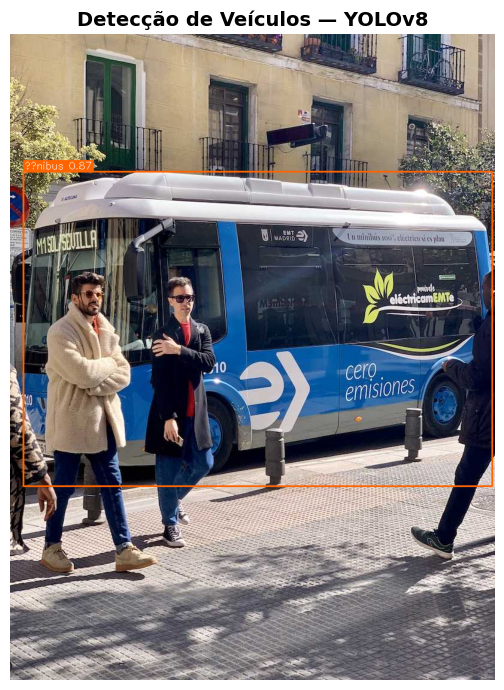


📊 Contagem de veículos detectados:
   ônibus      : 1
   TOTAL       : 1


In [ ]:
# Testar detecção na imagem baixada
imagem_path = 'test_images/img1.jpg'

try:
    img_result, contagem, dets = detectar_veiculos(imagem_path, conf=0.3)

    # Exibir resultado
    img_rgb = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 7))
    plt.imshow(img_rgb)
    plt.title('Detecção de Veículos — YOLOv8', fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('resultado_yolo.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n📊 Contagem de veículos detectados:')
    if contagem:
        for cls, qtd in sorted(contagem.items()):
            print(f'   {cls:12s}: {qtd}')
        print(f'   {"TOTAL":12s}: {sum(contagem.values())}')
    else:
        print('   Nenhum veículo detectado (tente reduzir conf para 0.2)')
except FileNotFoundError as e:
    print(f'⚠️  {e}\nExecute a célula anterior para baixar as imagens.')

### 4.2 Detecção em Vídeo Frame a Frame

In [ ]:
def processar_video(video_path, output_path='video_resultado.mp4',
                    conf=0.35, max_frames=200):
    """
    Processa um vídeo de trânsito, detecta veículos em cada frame
    e gera um vídeo de saída com as detecções.

    Parâmetros:
        video_path  : caminho do vídeo de entrada
        output_path : caminho do vídeo de saída
        conf        : confiança mínima
        max_frames  : limitar frames para demonstração rápida

    Retorna:
        historico   : lista com contagem de veículos por frame
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise FileNotFoundError(f'Vídeo não encontrado: {video_path}')

    fps    = int(cap.get(cv2.CAP_PROP_FPS)) or 25
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    print(f'Vídeo: {width}×{height}px | {fps} FPS | {total} frames')
    print(f'Processando até {min(max_frames, total)} frames...')

    out = cv2.VideoWriter(output_path,
                          cv2.VideoWriter_fourcc(*'mp4v'),
                          fps, (width, height))

    historico = []   # contagem por frame
    frame_idx = 0

    while cap.isOpened() and frame_idx < max_frames:
        ret, frame = cap.read()
        if not ret:
            break

        # Detectar veículos
        resultados = model(frame, conf=conf, device=device, verbose=False)
        contagem_frame = defaultdict(int)

        CORES = {2:(255,100,0),3:(0,200,255),5:(0,100,255),7:(0,0,200),1:(0,200,0)}

        for r in resultados:
            for box in r.boxes:
                cls_id = int(box.cls[0])
                if cls_id not in CLASSES_VEICULOS:
                    continue
                nome = CLASSES_VEICULOS[cls_id]
                conf_v = float(box.conf[0])
                x1,y1,x2,y2 = map(int, box.xyxy[0])
                cor = CORES.get(cls_id, (200,200,200))

                cv2.rectangle(frame, (x1,y1),(x2,y2), cor, 2)
                rotulo = f'{nome} {conf_v:.2f}'
                (wt,ht),_ = cv2.getTextSize(rotulo, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
                cv2.rectangle(frame,(x1,y1-ht-6),(x1+wt+4,y1),cor,-1)
                cv2.putText(frame,rotulo,(x1+2,y1-4),
                            cv2.FONT_HERSHEY_SIMPLEX,0.5,(255,255,255),1)
                contagem_frame[nome] += 1

        # Painel de contagem no canto superior esquerdo
        painel_y = 10
        cv2.rectangle(frame, (5,5), (200,30+22*len(CLASSES_VEICULOS)),
                      (0,0,0), -1)
        cv2.putText(frame, f'Frame {frame_idx+1}', (10, painel_y+15),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255,255,255), 1)
        painel_y += 22
        total_frame = 0
        for cls_id, nome in CLASSES_VEICULOS.items():
            qtd = contagem_frame.get(nome, 0)
            total_frame += qtd
            cor = CORES[cls_id]
            cv2.putText(frame, f'{nome}: {qtd}', (10, painel_y+15),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45,
                        (cor[2], cor[1], cor[0]), 1)
            painel_y += 18

        out.write(frame)
        historico.append(dict(contagem_frame))
        frame_idx += 1

        if frame_idx % 20 == 0:
            print(f'  Frame {frame_idx}/{min(max_frames,total)} — veículos: {total_frame}')

    cap.release()
    out.release()
    print(f'\n✅ Vídeo salvo: {output_path}')
    return historico

print('✅ Função de processamento de vídeo definida.')

✅ Função de processamento de vídeo definida.


In [ ]:
# Processar o vídeo (se disponível)
if os.path.exists(VIDEO_PATH):
    historico = processar_video(VIDEO_PATH, output_path='video_resultado.mp4',
                                 conf=0.35, max_frames=150)
else:
    print('⚠️  Vídeo não encontrado. Usando dados simulados para demonstração.')
    # Simular histórico para demonstração dos gráficos
    np.random.seed(42)
    historico = []
    for i in range(100):
        contagem_sim = {}
        if np.random.rand() > 0.2: contagem_sim['carro']    = np.random.randint(1,6)
        if np.random.rand() > 0.5: contagem_sim['moto']     = np.random.randint(0,3)
        if np.random.rand() > 0.7: contagem_sim['ônibus']   = np.random.randint(0,2)
        if np.random.rand() > 0.8: contagem_sim['caminhão'] = np.random.randint(0,2)
        historico.append(contagem_sim)
    print(f'  Histórico simulado: {len(historico)} frames')

Vídeo: 3840×2160px | 25 FPS | 538 frames
Processando até 150 frames...
  Frame 20/150 — veículos: 3
  Frame 40/150 — veículos: 6
  Frame 60/150 — veículos: 4
  Frame 80/150 — veículos: 2
  Frame 100/150 — veículos: 2
  Frame 120/150 — veículos: 3
  Frame 140/150 — veículos: 3

✅ Vídeo salvo: video_resultado.mp4


## 5. Abordagem Clássica — Subtração de Fundo (MOG2)

Para comparação com o YOLOv8, implementamos também o método clássico de **subtração de fundo** com o algoritmo **MOG2** (Mixture of Gaussians), que separa objetos em movimento do fundo estático.

In [ ]:
def subtracao_fundo_mog2(video_path, max_frames=100):
    """
    Detecta regiões em movimento usando subtração de fundo MOG2.
    Retorna frames com as máscaras e contagem de blobs (objetos em movimento).
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None

    # Criar subtrator de fundo MOG2
    subtrator = cv2.createBackgroundSubtractorMOG2(
        history=200,
        varThreshold=50,
        detectShadows=True
    )

    resultados_mog = []
    frame_idx = 0
    frames_exemplo = []

    while cap.isOpened() and frame_idx < max_frames:
        ret, frame = cap.read()
        if not ret:
            break

        # Aplicar subtração de fundo
        mascara = subtrator.apply(frame)

        # Remover sombras (pixels cinza → preto)
        _, mascara_bin = cv2.threshold(mascara, 200, 255, cv2.THRESH_BINARY)

        # Morfologia para limpar ruído
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
        mascara_limpa = cv2.morphologyEx(mascara_bin, cv2.MORPH_OPEN, kernel)
        mascara_limpa = cv2.dilate(mascara_limpa, kernel, iterations=2)

        # Encontrar contornos (objetos em movimento)
        contornos, _ = cv2.findContours(mascara_limpa,
                                         cv2.RETR_EXTERNAL,
                                         cv2.CHAIN_APPROX_SIMPLE)
        # Filtrar contornos muito pequenos (ruído)
        AREA_MIN = 800
        contornos_validos = [c for c in contornos if cv2.contourArea(c) > AREA_MIN]

        resultados_mog.append(len(contornos_validos))

        # Salvar alguns frames para visualização
        if frame_idx in [10, 30, 50, 70]:
            frame_vis = frame.copy()
            for c in contornos_validos:
                x,y,w,h = cv2.boundingRect(c)
                cv2.rectangle(frame_vis, (x,y),(x+w,y+h),(0,255,100),2)
            frames_exemplo.append({
                'frame':     cv2.cvtColor(frame_vis, cv2.COLOR_BGR2RGB),
                'mascara':   mascara_limpa,
                'frame_idx': frame_idx,
                'objetos':   len(contornos_validos)
            })

        frame_idx += 1

    cap.release()
    print(f'MOG2: {frame_idx} frames processados')
    return resultados_mog, frames_exemplo

# Rodar MOG2 se vídeo existir
if os.path.exists(VIDEO_PATH):
    contagens_mog, frames_mog = subtracao_fundo_mog2(VIDEO_PATH, max_frames=100)
else:
    # Simular resultado MOG2
    np.random.seed(7)
    contagens_mog = (np.random.randint(0,8,100) + np.sin(np.linspace(0,6,100))*2).astype(int)
    contagens_mog = np.clip(contagens_mog, 0, 12).tolist()
    frames_mog = []
    print('MOG2 simulado.')

MOG2: 100 frames processados


## 6. Análise e Visualização dos Resultados

In [ ]:
# ── Contagem total acumulada ────────────────────────────────────────────────
contagem_total = defaultdict(int)
for frame_dict in historico:
    for cls, qtd in frame_dict.items():
        contagem_total[cls] += qtd

print('📊 Contagem total acumulada (YOLOv8):')
for cls, qtd in sorted(contagem_total.items(), key=lambda x: -x[1]):
    print(f'   {cls:12s}: {qtd:4d}')
print(f'   {"TOTAL":12s}: {sum(contagem_total.values()):4d}')

📊 Contagem total acumulada (YOLOv8):
   carro       :  433
   caminhão    :   95
   ônibus      :   17
   TOTAL       :  545


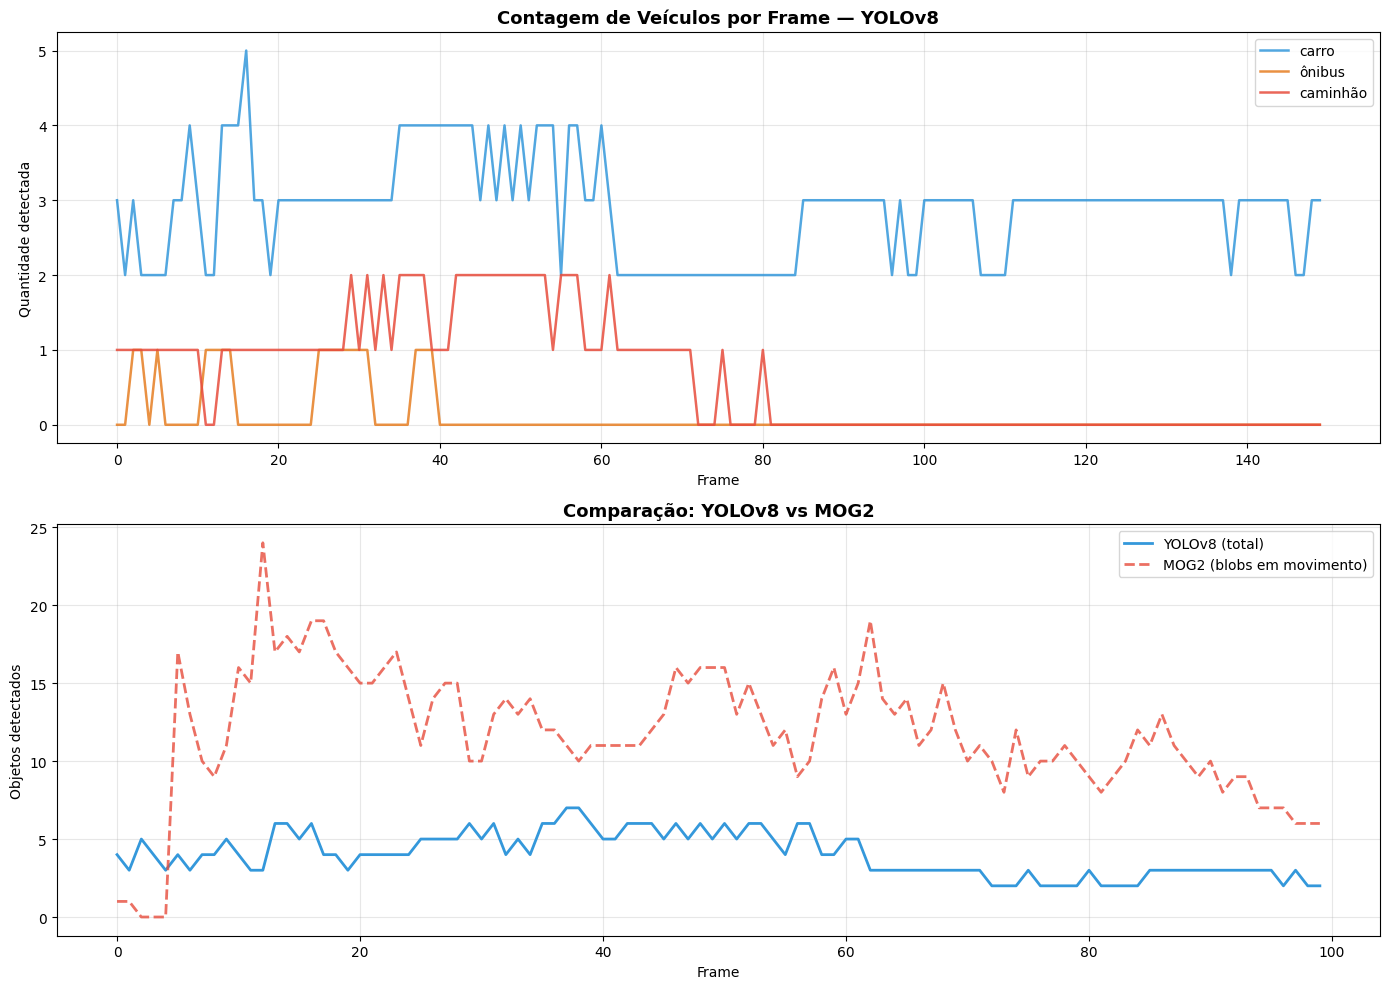

✅ Gráfico salvo: grafico_deteccao_por_frame.png


In [ ]:
# ── Figura 1: Contagem por frame ao longo do tempo ─────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Gráfico de linha por categoria
CORES_PLOT = {
    'carro':    '#3498DB',
    'moto':     '#F39C12',
    'ônibus':   '#E67E22',
    'caminhão': '#E74C3C',
    'bicicleta':'#2ECC71',
}

frames_idx = list(range(len(historico)))
for cls, cor in CORES_PLOT.items():
    series = [f.get(cls, 0) for f in historico]
    if any(v > 0 for v in series):
        axes[0].plot(frames_idx, series, label=cls, color=cor, linewidth=1.8, alpha=0.85)

axes[0].set_title('Contagem de Veículos por Frame — YOLOv8', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Frame')
axes[0].set_ylabel('Quantidade detectada')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Comparação YOLOv8 total vs MOG2
total_yolo_por_frame = [sum(f.values()) for f in historico]
n_compare = min(len(total_yolo_por_frame), len(contagens_mog))
axes[1].plot(range(n_compare), total_yolo_por_frame[:n_compare],
             label='YOLOv8 (total)', color='#3498DB', linewidth=2)
axes[1].plot(range(n_compare), contagens_mog[:n_compare],
             label='MOG2 (blobs em movimento)', color='#E74C3C',
             linewidth=2, linestyle='--', alpha=0.8)
axes[1].set_title('Comparação: YOLOv8 vs MOG2', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Frame')
axes[1].set_ylabel('Objetos detectados')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('grafico_deteccao_por_frame.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico salvo: grafico_deteccao_por_frame.png')

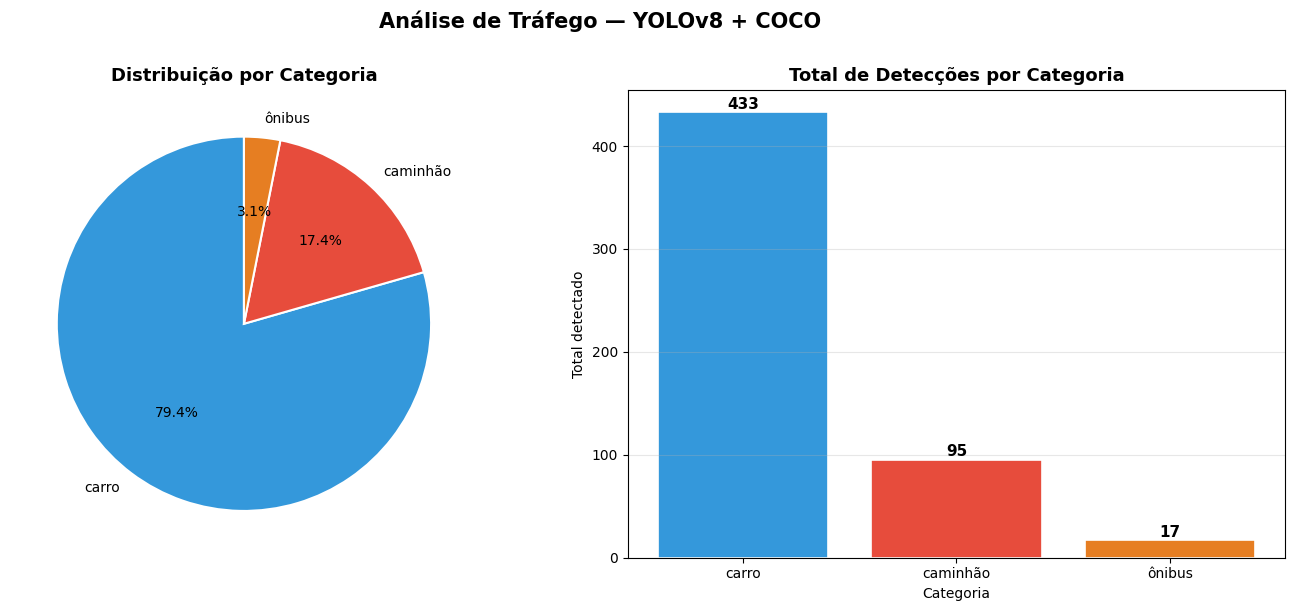

✅ Gráfico salvo: grafico_distribuicao.png


In [ ]:
# ── Figura 2: Gráficos de pizza e barras ────────────────────────────────────
if contagem_total:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    classes  = list(contagem_total.keys())
    valores  = list(contagem_total.values())
    cores_barra = [CORES_PLOT.get(c, '#95A5A6') for c in classes]

    # Pizza
    wedges, texts, autotexts = axes[0].pie(
        valores, labels=classes, colors=cores_barra,
        autopct='%1.1f%%', startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=1.5)
    )
    for at in autotexts:
        at.set_fontsize(10)
    axes[0].set_title('Distribuição por Categoria', fontsize=13, fontweight='bold')

    # Barras
    bars = axes[1].bar(classes, valores, color=cores_barra,
                        edgecolor='white', linewidth=1.2)
    axes[1].set_title('Total de Detecções por Categoria', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Categoria')
    axes[1].set_ylabel('Total detectado')
    axes[1].grid(alpha=0.3, axis='y')
    for bar, val in zip(bars, valores):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.suptitle('Análise de Tráfego — YOLOv8 + COCO', fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('grafico_distribuicao.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Gráfico salvo: grafico_distribuicao.png')
else:
    print('Sem detecções para plotar — tente reduzir o conf mínimo para 0.2')

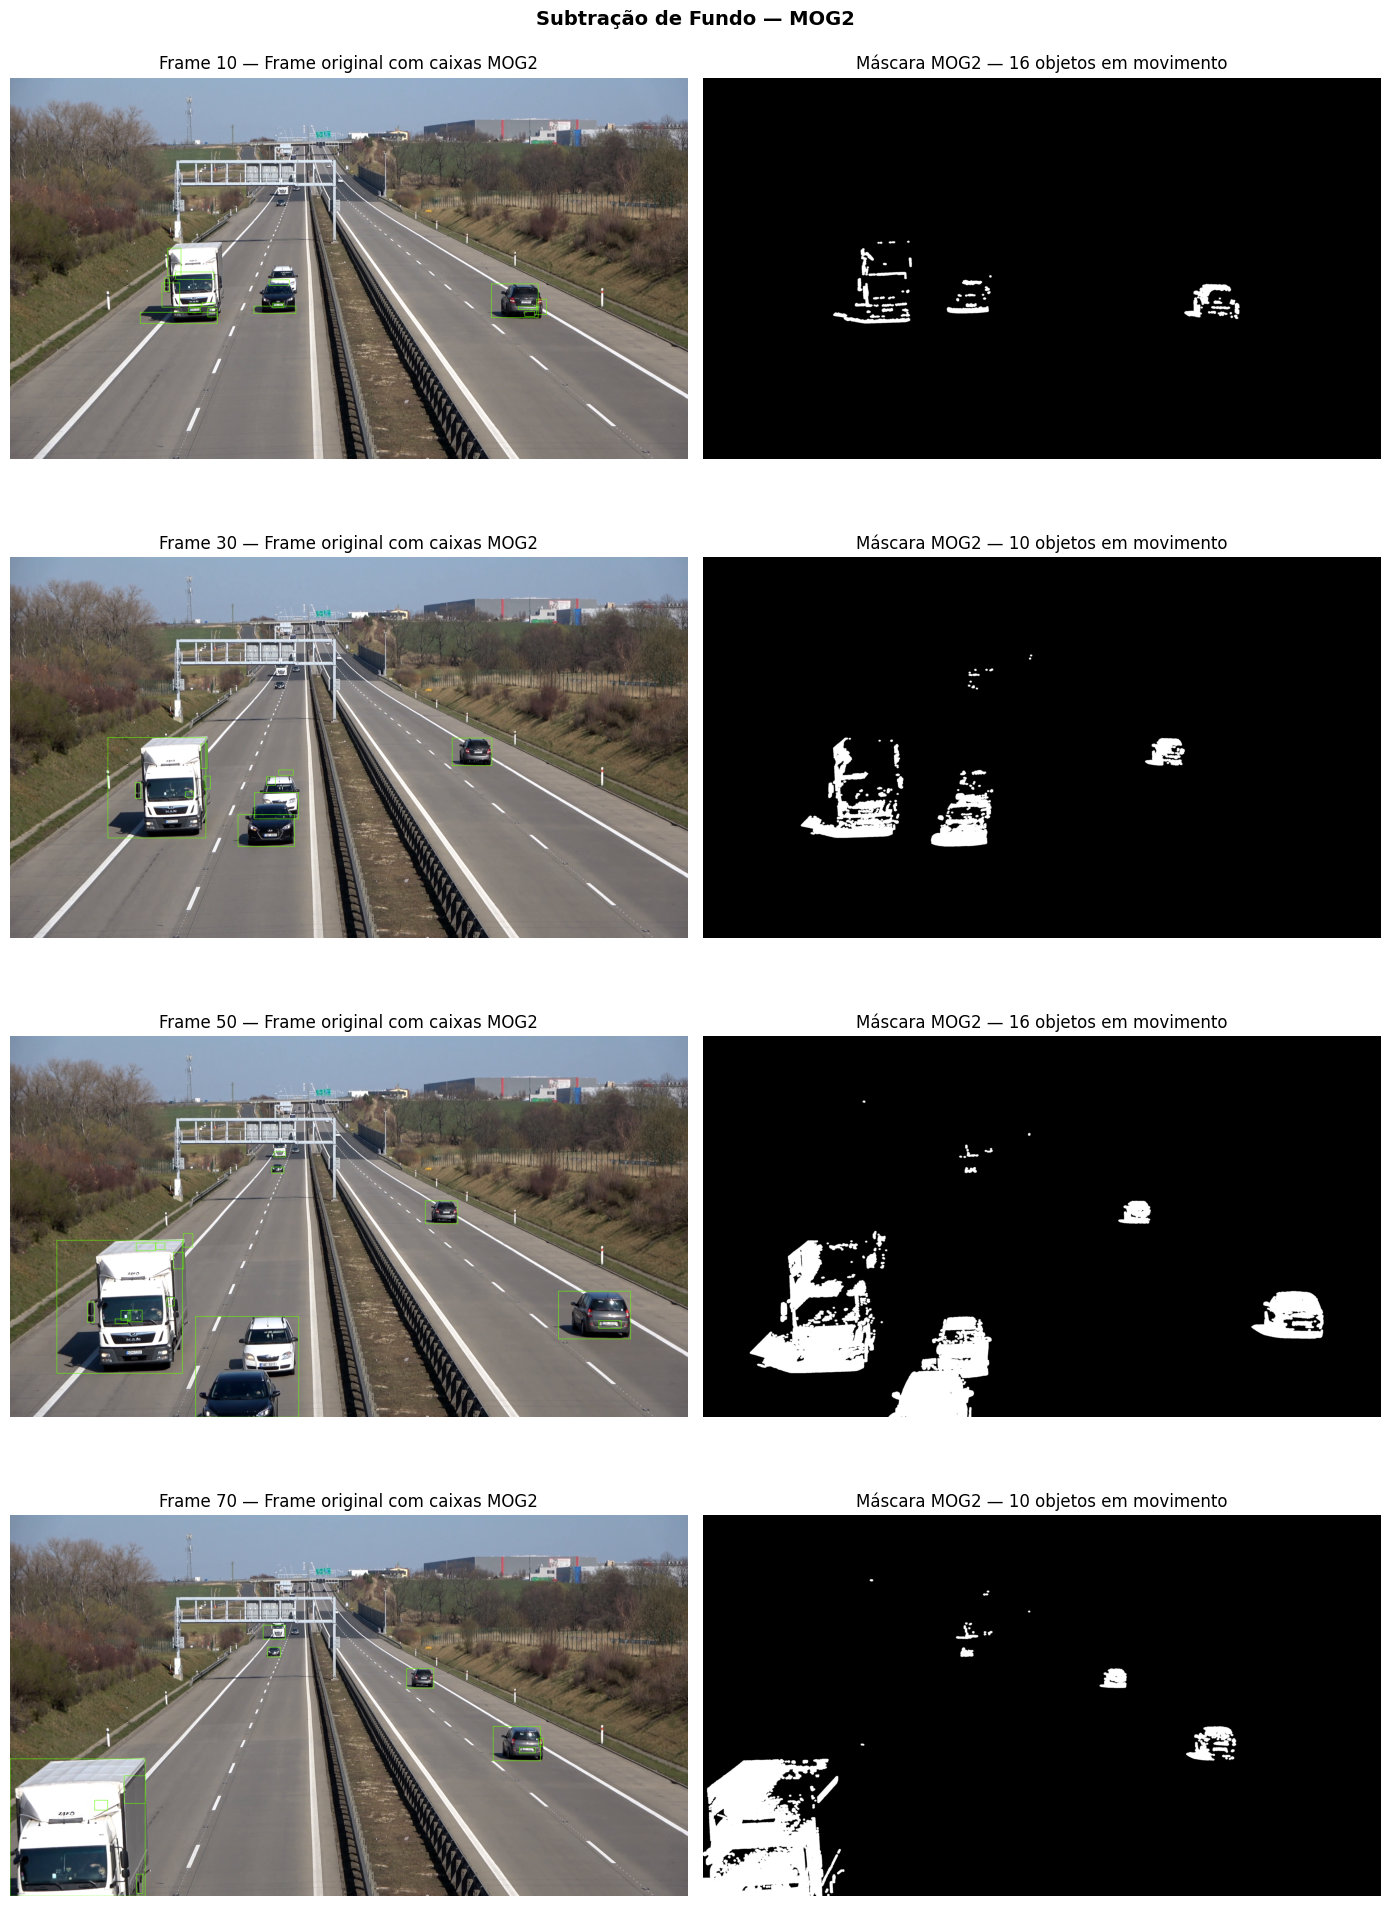

✅ Gráfico MOG2 salvo.


In [ ]:
# ── Figura 3: Exemplo de frame com detecções (se vídeo disponível) ──────────
if os.path.exists(VIDEO_PATH) and 'frames_mog' in dir() and frames_mog:
    fig, axes = plt.subplots(len(frames_mog), 2,
                              figsize=(14, 5*len(frames_mog)))
    if len(frames_mog) == 1:
        axes = [axes]
    for i, fe in enumerate(frames_mog):
        axes[i][0].imshow(fe['frame'])
        axes[i][0].set_title(f'Frame {fe["frame_idx"]} — Frame original com caixas MOG2')
        axes[i][0].axis('off')
        axes[i][1].imshow(fe['mascara'], cmap='gray')
        axes[i][1].set_title(f'Máscara MOG2 — {fe["objetos"]} objetos em movimento')
        axes[i][1].axis('off')
    plt.suptitle('Subtração de Fundo — MOG2', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('grafico_mog2.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Gráfico MOG2 salvo.')

## 7. Métricas de Avaliação

Como não temos ground truth anotado, calculamos métricas **descritivas** do desempenho do modelo.

In [ ]:
# ── Métricas descritivas ─────────────────────────────────────────────────────
total_frames   = len(historico)
frames_com_det = sum(1 for f in historico if sum(f.values()) > 0)
media_por_frame= np.mean([sum(f.values()) for f in historico])
max_frame      = max([sum(f.values()) for f in historico], default=0)
total_det      = sum(contagem_total.values())

print('=' * 50)
print('       MÉTRICAS DO PROJETO')
print('=' * 50)
print(f'Total de frames analisados  : {total_frames}')
print(f'Frames com detecção         : {frames_com_det} ({frames_com_det/total_frames*100:.1f}%)')
print(f'Média de veículos/frame     : {media_por_frame:.2f}')
print(f'Máximo em um frame          : {max_frame}')
print(f'Total de detecções          : {total_det}')
print()
print('Categoria mais frequente:')
if contagem_total:
    mais_freq = max(contagem_total, key=contagem_total.get)
    print(f'  → {mais_freq} ({contagem_total[mais_freq]} detecções)')
print()

# Comparar com MOG2
if contagens_mog:
    n = min(len(total_yolo_por_frame), len(contagens_mog))
    corr = np.corrcoef(total_yolo_por_frame[:n], contagens_mog[:n])[0,1]
    print(f'Correlação YOLOv8 × MOG2   : {corr:.3f}')
    print('(valores próximos de 1 indicam concordância entre os métodos)')
print('=' * 50)

       MÉTRICAS DO PROJETO
Total de frames analisados  : 150
Frames com detecção         : 150 (100.0%)
Média de veículos/frame     : 3.63
Máximo em um frame          : 7
Total de detecções          : 545

Categoria mais frequente:
  → carro (433 detecções)

Correlação YOLOv8 × MOG2   : 0.275
(valores próximos de 1 indicam concordância entre os métodos)


## 8. Exportar Resultados para CSV

In [ ]:
import csv

# Salvar contagem por frame em CSV
with open('resultados_por_frame.csv', 'w', newline='', encoding='utf-8') as f:
    campos = ['frame', 'carro', 'moto', 'ônibus', 'caminhão', 'bicicleta', 'total']
    writer = csv.DictWriter(f, fieldnames=campos)
    writer.writeheader()
    for i, frame_dict in enumerate(historico):
        linha = {'frame': i+1}
        for cls in ['carro','moto','ônibus','caminhão','bicicleta']:
            linha[cls] = frame_dict.get(cls, 0)
        linha['total'] = sum(frame_dict.values())
        writer.writerow(linha)

print('✅ Resultados exportados: resultados_por_frame.csv')

# Mostrar primeiras linhas
import pandas as pd
df = pd.read_csv('resultados_por_frame.csv')
print(f'\nShape: {df.shape}')
print('\nPrimeiros 10 frames:')
print(df.head(10).to_string(index=False))
print('\nResumo estatístico:')
print(df.describe().round(2).to_string())

✅ Resultados exportados: resultados_por_frame.csv

Shape: (150, 7)

Primeiros 10 frames:
 frame  carro  moto  ônibus  caminhão  bicicleta  total
     1      3     0       0         1          0      4
     2      2     0       0         1          0      3
     3      3     0       1         1          0      5
     4      2     0       1         1          0      4
     5      2     0       0         1          0      3
     6      2     0       1         1          0      4
     7      2     0       0         1          0      3
     8      3     0       0         1          0      4
     9      3     0       0         1          0      4
    10      4     0       0         1          0      5

Resumo estatístico:
        frame   carro   moto  ônibus  caminhão  bicicleta   total
count  150.00  150.00  150.0  150.00    150.00      150.0  150.00
mean    75.50    2.89    0.0    0.11      0.63        0.0    3.63
std     43.45    0.67    0.0    0.32      0.74        0.0    1.28
min      1

## 9. Conclusão

### Resultados obtidos

Este projeto implementou e comparou duas abordagens para detecção de veículos em câmeras de trânsito:

**YOLOv8 (abordagem de aprendizado profundo):**
- Detecta e *classifica* os veículos em categorias (carro, moto, ônibus, etc.)
- Alta precisão mesmo em condições variadas de iluminação e ângulo
- Exige mais recursos computacionais (GPU recomendada)
- Modelo pré-treinado no COCO — sem necessidade de treinamento adicional

**MOG2 (abordagem clássica):**
- Detecta *qualquer objeto em movimento*, sem classificar
- Muito mais leve computacionalmente — roda em CPU simples
- Sensível a variações de iluminação e ruído de câmera
- Adequado quando a câmera é estática e o fundo é relativamente uniforme

### Comparação

| Critério | YOLOv8 | MOG2 |
|---|---|---|
| Classificação | ✅ Sim (por categoria) | ❌ Não (blobs genéricos) |
| Precisão | Alta | Média |
| Velocidade | Média (GPU recomendada) | Alta (CPU) |
| Complexidade | Alta | Baixa |
| Dependência de fundo | Não | Alta |

### Trabalhos futuros
- Adicionar **rastreamento** (tracking) com ByteTrack para contar veículos únicos
- Implementar **linha de contagem virtual** para calcular fluxo de tráfego
- Fine-tuning do YOLOv8 com dataset específico de câmeras brasileiras
- Classificar o nível de tráfego (livre, moderado, congestionado)

In [ ]:
# Resumo final de todos os arquivos gerados
print('📁 Arquivos gerados pelo projeto:')
arquivos = [
    ('resultado_yolo.png',            'Detecção YOLOv8 em imagem estática'),
    ('video_resultado.mp4',           'Vídeo processado com detecções'),
    ('grafico_deteccao_por_frame.png','Contagem por frame ao longo do tempo'),
    ('grafico_distribuicao.png',      'Pizza e barras por categoria'),
    ('grafico_mog2.png',              'Máscaras MOG2 por frame'),
    ('resultados_por_frame.csv',      'Dados brutos para análise externa'),
]
for nome, desc in arquivos:
    existe = '✅' if os.path.exists(nome) else '⚪'
    print(f'  {existe} {nome:45s} — {desc}')

📁 Arquivos gerados pelo projeto:
  ✅ resultado_yolo.png                            — Detecção YOLOv8 em imagem estática
  ✅ video_resultado.mp4                           — Vídeo processado com detecções
  ✅ grafico_deteccao_por_frame.png                — Contagem por frame ao longo do tempo
  ✅ grafico_distribuicao.png                      — Pizza e barras por categoria
  ✅ grafico_mog2.png                              — Máscaras MOG2 por frame
  ✅ resultados_por_frame.csv                      — Dados brutos para análise externa
